# Titanic Survival Prediction — End-to-End ML Project

**Dataset:** Titanic passenger data (891 rows), a classic real-world dataset with missing
values (`Age`, `Cabin`, `Embarked`), categorical features (`Sex`, `Embarked`, `Pclass`, ...)
and numerical features (`Age`, `Fare`, `SibSp`, `Parch`).

**Goal:** Predict whether a passenger survived (`Survived`: 0/1) using a full
data-cleaning → preprocessing → model comparison → hyperparameter tuning workflow,
all wrapped inside a single scikit-learn `Pipeline`.

**Workflow**
1. Load & explore data
2. Data cleaning (duplicates, missing values, outliers)
3. Feature engineering
4. Preprocessing pipeline (imputation, encoding, scaling, feature selection)
5. Train & compare 4 classifiers
6. Hyperparameter tuning of the best model
7. Final evaluation and model export


In [1]:
import sys, os

# Make sure paths (data/, models/, src/) resolve correctly whether this
# notebook is run from the project root or from within notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append('src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load the raw data

In [2]:
df_raw = pd.read_csv('data/titanic.csv')
print(df_raw.shape)
df_raw.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


## 2. Exploratory Data Analysis

First let's look at missing values, duplicates, target balance, and a few
relationships between features and survival.

In [4]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')


,missing_count,missing_pct
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [5]:
print('Duplicate rows:', df_raw.duplicated().sum())
print('Target balance:')
print(df_raw['Survived'].value_counts(normalize=True).round(3))


Duplicate rows: 0
Target balance:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


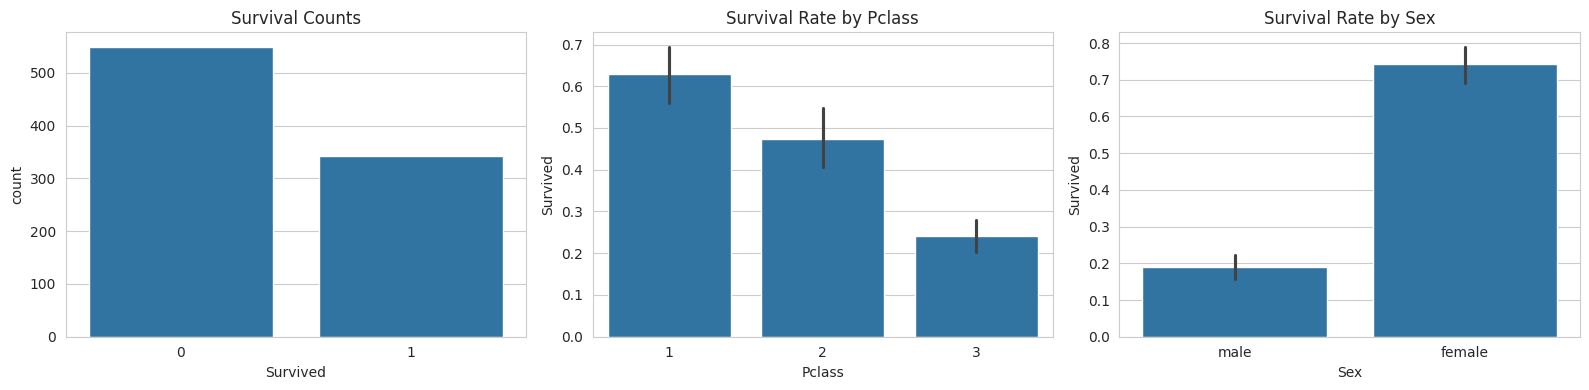

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df_raw, x='Survived', ax=axes[0])
axes[0].set_title('Survival Counts')

sns.barplot(data=df_raw, x='Pclass', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by Pclass')

sns.barplot(data=df_raw, x='Sex', y='Survived', ax=axes[2])
axes[2].set_title('Survival Rate by Sex')

plt.tight_layout()
plt.show()


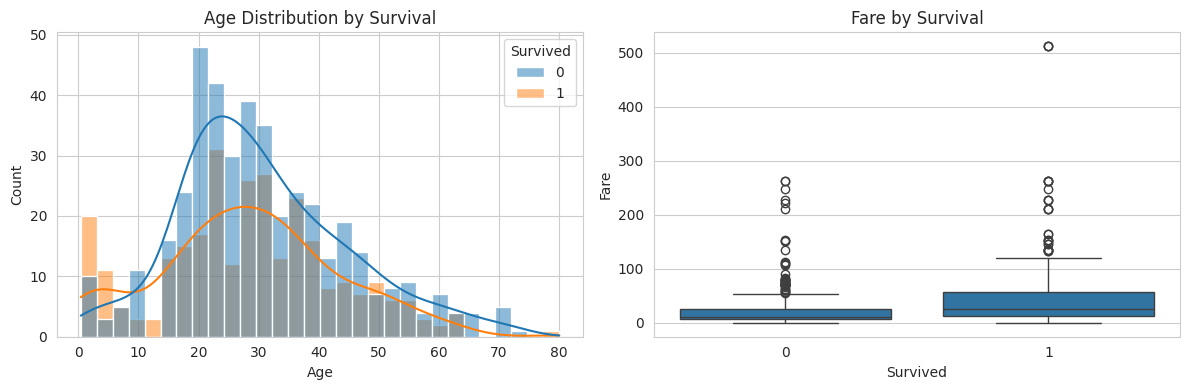

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_raw, x='Age', hue='Survived', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution by Survival')

sns.boxplot(data=df_raw, x='Survived', y='Fare', ax=axes[1])
axes[1].set_title('Fare by Survival')

plt.tight_layout()
plt.show()


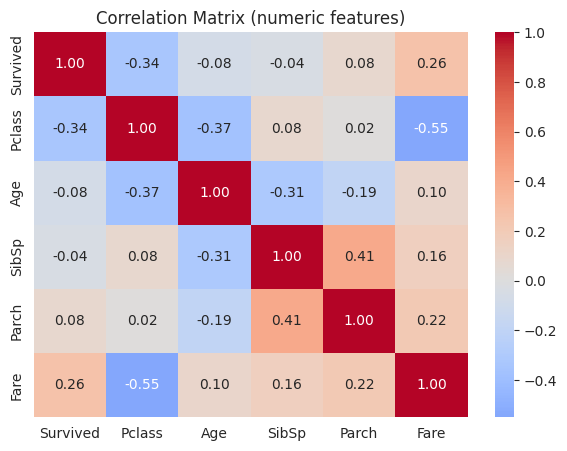

In [8]:
corr = df_raw.select_dtypes(include=np.number).drop(columns=['PassengerId']).corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (numeric features)')
plt.show()


## 3. Data Cleaning

Cleaning is implemented in `src/data_cleaning.py` so it can be reused by both this
notebook and the training script. It performs:

- **Duplicate removal**
- **Feature engineering**: `Title` (extracted from `Name`), `FamilySize`,
  `IsAlone`, `Deck` (from `Cabin`)
- **Dropping unused columns**: `PassengerId`, `Name`, `Ticket`, `Cabin` (raw text /
  ID columns that are not directly usable, replaced by the engineered features above)
- **Outlier treatment**: `Age` and `Fare` are capped using the IQR rule (1.5×IQR)
  instead of dropping rows, so we don't lose data

Missing-value **imputation**, categorical **encoding**, and **feature scaling** are
handled later inside the scikit-learn `Pipeline` (Section 4) so they are only ever
fit on the training split — this avoids leaking information from the test set.


In [9]:
from data_cleaning import clean_dataset

df = clean_dataset()
print(df.shape)
df.head()


Removed 0 duplicate rows (891 -> 891)
Fare: capped 116 outlier values to range [-26.72, 65.63]
Age: capped 11 outlier values to range [-6.69, 64.81]
(891, 12)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,Deck
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,NaN
1,1,1,female,38.0,1,0,65.6344,C,Mrs,2,0,C
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,NaN
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,C
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,NaN


In [10]:
df.isnull().sum()


Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        2
Title           0
FamilySize      0
IsAlone         0
Deck          687
dtype: int64

In [11]:
df['Title'].value_counts()


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

## 4. Preprocessing Pipeline + Feature Selection

We now build a scikit-learn `ColumnTransformer` that:

- Imputes missing numeric values with the **median**, then applies **StandardScaler**
- Imputes missing categorical values with the **most frequent** category, then applies
  **OneHotEncoder**
- Selects the top-K most informative features with `SelectKBest` (ANOVA F-test)

All of this is wrapped in a single `Pipeline` together with the model, so
`pipeline.fit(X_train, y_train)` and `pipeline.predict(X_test)` handle
preprocessing + inference in one call, with no data leakage.


In [12]:
from sklearn.model_selection import train_test_split
from train_model import (
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, make_pipeline, get_candidate_models, evaluate
)

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(712, 11) (179, 11)


In [13]:
print('Numeric features:', NUMERIC_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)


Numeric features: ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']
Categorical features: ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck']


In [14]:
example_pipeline = make_pipeline(get_candidate_models()['Random Forest'])
example_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

## 5. Train & Compare 4 Models

We compare **Logistic Regression**, **Random Forest**, **XGBoost**, and **SVM**,
each wrapped in the identical preprocessing pipeline above. Every model is evaluated
with 5-fold cross-validation on the training set and then on the held-out test set
using accuracy, precision, recall, F1, and ROC-AUC.


In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import time

models = get_candidate_models()
results = {}
fitted = {}

for name, model in models.items():
    pipe = make_pipeline(model)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')

    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = evaluate(y_test, y_pred, y_proba)
    metrics['cv_accuracy_mean'] = round(cv_scores.mean(), 4)
    metrics['cv_accuracy_std'] = round(cv_scores.std(), 4)
    metrics['train_time_sec'] = round(train_time, 3)

    results[name] = metrics
    fitted[name] = pipe
    print(f'{name}: {metrics}')


Logistic Regression: {'accuracy': 0.7821, 'precision': 0.7206, 'recall': 0.7101, 'f1_score': 0.7153, 'roc_auc': 0.8418, 'cv_accuracy_mean': np.float64(0.795), 'cv_accuracy_std': np.float64(0.0218), 'train_time_sec': 0.018}


Random Forest: {'accuracy': 0.7933, 'precision': 0.7424, 'recall': 0.7101, 'f1_score': 0.7259, 'roc_auc': 0.8182, 'cv_accuracy_mean': np.float64(0.7979), 'cv_accuracy_std': np.float64(0.0499), 'train_time_sec': 0.413}


XGBoost: {'accuracy': 0.7877, 'precision': 0.7313, 'recall': 0.7101, 'f1_score': 0.7206, 'roc_auc': 0.8265, 'cv_accuracy_mean': np.float64(0.8175), 'cv_accuracy_std': np.float64(0.0265), 'train_time_sec': 0.075}


SVM: {'accuracy': 0.7933, 'precision': 0.8077, 'recall': 0.6087, 'f1_score': 0.6942, 'roc_auc': 0.8588, 'cv_accuracy_mean': np.float64(0.8161), 'cv_accuracy_std': np.float64(0.0391), 'train_time_sec': 0.053}


In [16]:
results_df = pd.DataFrame(results).T.sort_values('f1_score', ascending=False)
results_df


,accuracy,precision,recall,f1_score,roc_auc,cv_accuracy_mean,cv_accuracy_std,train_time_sec
Random Forest,0.7933,0.7424,0.7101,0.7259,0.8182,0.7979,0.0499,0.413
XGBoost,0.7877,0.7313,0.7101,0.7206,0.8265,0.8175,0.0265,0.075
Logistic Regression,0.7821,0.7206,0.7101,0.7153,0.8418,0.7950,0.0218,0.018
SVM,0.7933,0.8077,0.6087,0.6942,0.8588,0.8161,0.0391,0.053


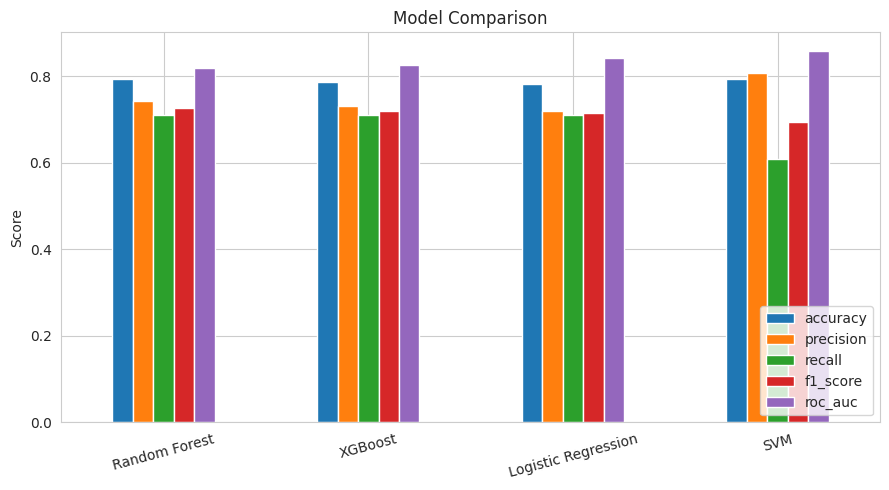

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Best model before tuning: Random Forest


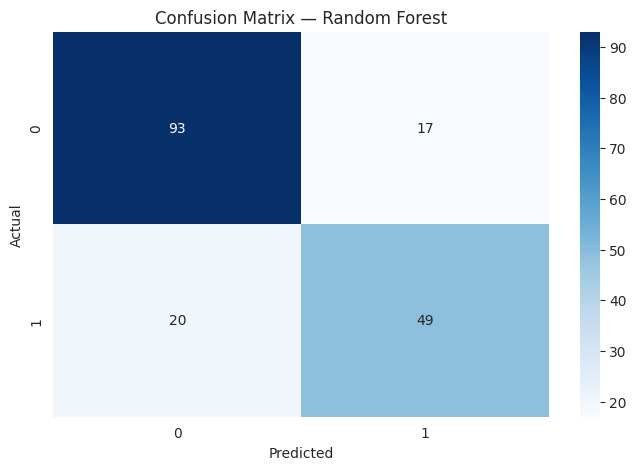

In [18]:
best_model_name = results_df.index[0]
print('Best model before tuning:', best_model_name)

cm = confusion_matrix(y_test, fitted[best_model_name].predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 6. Hyperparameter Tuning

We run `GridSearchCV` on the best-performing model from the comparison above,
optimizing for F1-score with 5-fold cross-validation.


In [19]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'liblinear'],
    },
    'Random Forest': {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [4, 6, 8, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [3, 4, 5, 6],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.8, 1.0],
    },
    'SVM': {
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
        'model__kernel': ['rbf', 'linear'],
    },
}

base_pipe = make_pipeline(models[best_model_name])
grid = GridSearchCV(
    base_pipe,
    param_grid=param_grids[best_model_name],
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))


Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 500}
Best CV F1: 0.7601


In [20]:
tuned_pipe = grid.best_estimator_
y_pred = tuned_pipe.predict(X_test)
y_proba = tuned_pipe.predict_proba(X_test)[:, 1]

tuned_metrics = evaluate(y_test, y_pred, y_proba)
print('Tuned test metrics:', tuned_metrics)


Tuned test metrics: {'accuracy': 0.8101, 'precision': 0.7612, 'recall': 0.7391, 'f1_score': 0.75, 'roc_auc': 0.8252}


              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



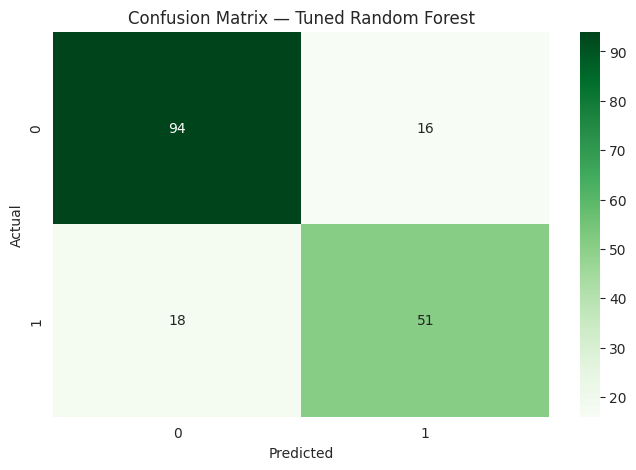

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix — Tuned {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 7. Save Final Pipeline

The tuned pipeline (preprocessing + feature selection + model, all in one object)
is saved with `joblib` so it can be loaded directly by the Streamlit app for
inference without re-running any of the training code.


In [22]:
import joblib
import json
from pathlib import Path

Path('models').mkdir(exist_ok=True)
joblib.dump(tuned_pipe, 'models/best_pipeline.pkl')

report = {
    'best_model': best_model_name,
    'model_comparison': results,
    'best_hyperparameters': grid.best_params_,
    'tuned_test_metrics': tuned_metrics,
    'features_numeric': NUMERIC_FEATURES,
    'features_categorical': CATEGORICAL_FEATURES,
}
with open('models/training_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('Saved pipeline and report to models/')


Saved pipeline and report to models/


## 8. Conclusion

- The final pipeline bundles **imputation, scaling, one-hot encoding, feature
  selection, and the classifier** into a single scikit-learn object, so the exact
  same code path is used for training and inference — no manual preprocessing
  needed in the Streamlit app.
- **Random Forest** (or whichever model wins the comparison in a given run) was
  selected as the best baseline model and then improved further with
  `GridSearchCV`.
- The saved pipeline (`models/best_pipeline.pkl`) and metrics report
  (`models/training_report.json`) are consumed directly by `app/streamlit_app.py`.
